In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from scipy.ndimage import median_filter
import sys
import os
import struct
from pathlib import Path
import pickle

# Add project 'src' directory to sys.path when running from the notebooks/ folder
# (notebooks/ is expected to be inside the repo; repo_root = parent of cwd)
repo_root = Path.cwd().parent
src_path = str(repo_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Import modules from the installed package. If this fails, the editable install
# (`pip install -e .`) may be missing or kernel needs restart.
try:
    from ec.func_read_data import *
    from mo.func_mo import *
    from spc.normalize import *
    from plotting.funcs_plots import *
    from ec.sensor_info import *
    from ec.func_dr import *
    from ec.func_mrfd import *
except Exception as e:
    print('Package import failed:', e)
    print('Make sure you ran `pip install -e .` (editable install) and restart the kernel, or that src/ exists at:', src_path)
else:
    # For development: auto-reload modules (keep this enabled while editing source files)
    %load_ext autoreload
    %autoreload 2


import wrf
import glob
import xarray as xr
import netCDF4
from datetime import datetime, timedelta
from scipy.interpolate import griddata


In [2]:
import wrf
import glob
import xarray as xr
import netCDF4
from datetime import datetime, timedelta
from scipy.interpolate import griddata


In [3]:
"""READ IN LOWDATA FILES"""
folder_observations = Path('/capstor/scratch/cscs/rengbers/slow_data/')
data_obs=read_data(folder_observations, 'slow', sensor='SFC')
data_obs=clean_slowdata(data_obs)


"""READ IN EDDYPRO FILES"""
folder_ec = Path('/capstor/scratch/cscs/rengbers/ec_data/')
sensor='SFC_DR'
fluxes_SFC = read_eddypro_data(folder_ec, sensor)
fluxes_SFC_qc = read_eddypro_data(folder_ec, sensor, qc=True)
sensor='CSAT_16m_DR'
fluxes_16m = read_eddypro_data(folder_ec, sensor)
fluxes_16m_qc = read_eddypro_data(folder_ec, sensor, qc=True)
sensor='CSAT_26m_DR'
fluxes_26m = read_eddypro_data(folder_ec, sensor)
fluxes_26m_qc = read_eddypro_data(folder_ec, sensor, qc=True)


"READ MO FLUX DATA"
folder="../"
MO_data=pd.read_csv(folder+'MO_fluxes_2024.csv', parse_dates=['time'], index_col=['time'])

Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240118_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240120_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240122_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240201_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240205_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240214_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20240220_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20241223_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250208_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250211_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250821_SFC
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250821_SFC/02
Reading data from /capstor/scratch/cscs/rengbers/slow_data/20250821_SFC/02/11
Found wind file: CR6_STN1wind.csv
Reading data from /ca

/users/rengbers/DataProcessingScripts/src/ec/func_read_data.py:458: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file, header=1) for file in files],
/users/rengbers/DataProcessingScripts/src/ec/func_read_data.py:458: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file, header=1) for file in files],
/users/rengbers/DataProcessingScripts/src/ec/func_read_data.py:458: Dt

Files found: ['/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202407/eddypro_Jul2024_qc_details_2025-05-22T164622_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202412/eddypro_Dec2024_qc_details_2025-05-23T123929_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202402/eddypro_Feb2024_qc_details_2025-05-22T112810_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202405/eddypro_May2024_qc_details_2025-05-22T145422_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202411/eddypro_Nov2024_qc_details_2025-05-23T115956_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202410/eddypro_Oct2024_qc_details_2025-05-23T110946_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202403/eddypro_Mar2024_qc_details_2025-05-22T130802_adv.csv', '/capstor/scratch/cscs/rengbers/ec_data/SFC_DR/Eddypro_output/202409/eddypro_Sep2024_qc_details_2025-05-23T102118_adv.

In [4]:
coords_PEA = [-71.94958, 23.35013]  # lat, lon

In [24]:
"""
LOAD IN ALL NECESSARY DATA
"""
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d04'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf

wrflist=[]
pattern = str(folder_simulations / outhist_files)
for ncdf in sorted(glob.glob(pattern))[24:]:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist

# Get atmospheric surface variables
ter = wrf.getvar(wrflist, 'ter', timeidx=0, method="cat")
u10 = wrf.getvar(wrflist, "U10", timeidx=wrf.ALL_TIMES, method="cat")
v10 = wrf.getvar(wrflist, "V10", timeidx=wrf.ALL_TIMES, method="cat")
w10 = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
w10=w10.isel(bottom_top=0)
speed10 = np.sqrt(u10**2 + v10**2)
th2=wrf.getvar(wrflist, "TH2", timeidx=wrf.ALL_TIMES, method="cat")
t2=wrf.getvar(wrflist, "T2", timeidx=wrf.ALL_TIMES, method="cat")
q2=wrf.getvar(wrflist, "Q2", timeidx=wrf.ALL_TIMES, method="cat")
tsk=wrf.getvar(wrflist, "TSK", timeidx=wrf.ALL_TIMES, method="cat")
pb=wrf.getvar(wrflist, "PB", timeidx=wrf.ALL_TIMES, method="cat")
p=wrf.getvar(wrflist, "P", timeidx=wrf.ALL_TIMES, method="cat")
p=p+pb
p0=p.isel(bottom_top=0)
rh=wrf.rh(q2, p0,t2) 
rh=rh.assign_coords(Time=t2.Time)

lh=wrf.getvar(wrflist, "LH", timeidx=wrf.ALL_TIMES, method="cat")
hfx=wrf.getvar(wrflist, "HFX", timeidx=wrf.ALL_TIMES, method="cat")

z = wrf.getvar(wrflist, "z", timeidx=wrf.ALL_TIMES, method="cat")
theta = wrf.getvar(wrflist, 'theta', timeidx=wrf.ALL_TIMES, method="cat")
# t = wrf.getvar(wrflist, 'tc', timeidx=wrf.ALL_TIMES)
# q = wrf.getvar(wrflist, "QVAPOR", timeidx=wrf.ALL_TIMES) * 1000
u = wrf.getvar(wrflist, "ua", timeidx=wrf.ALL_TIMES, method="cat")
v = wrf.getvar(wrflist, "va", timeidx=wrf.ALL_TIMES, method="cat")
w = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
speed = np.sqrt(u**2 + v**2)

bs_qi=wrf.getvar(wrflist, "bs_qi", timeidx=wrf.ALL_TIMES, method="cat")



wind_dir = (np.arctan2(-u10, -v10) * 180 / np.pi) % 360
wind_dir.attrs['units'] = 'degrees'
wind_dir.attrs['description'] = 'Wind direction from u and v components'


"""
LOAD IN ALL NECESSARY DATA
"""
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d03'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf

wrflist=[]
pattern = str(folder_simulations / outhist_files)
for ncdf in sorted(glob.glob(pattern))[24:]:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist

# Get atmospheric surface variables
ter_d03 = wrf.getvar(wrflist, 'ter', timeidx=0, method="cat")
u10_d03 = wrf.getvar(wrflist, "U10", timeidx=wrf.ALL_TIMES, method="cat")
v10_d03 = wrf.getvar(wrflist, "V10", timeidx=wrf.ALL_TIMES, method="cat")
w10_d03 = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
w10_d03=w10_d03.isel(bottom_top=0)
speed10_d03 = np.sqrt(u10_d03**2 + v10_d03**2)
th2_d03=wrf.getvar(wrflist, "TH2", timeidx=wrf.ALL_TIMES, method="cat")
t2_d03=wrf.getvar(wrflist, "T2", timeidx=wrf.ALL_TIMES, method="cat")
q2_d03=wrf.getvar(wrflist, "Q2", timeidx=wrf.ALL_TIMES, method="cat")
tsk_d03=wrf.getvar(wrflist, "TSK", timeidx=wrf.ALL_TIMES, method="cat")
pb_d03=wrf.getvar(wrflist, "PB", timeidx=wrf.ALL_TIMES, method="cat")
p_d03=wrf.getvar(wrflist, "P", timeidx=wrf.ALL_TIMES, method="cat")
p_d03=p_d03+pb_d03
p0_d03=p_d03.isel(bottom_top=0)
rh_d03=wrf.rh(q2_d03, p0_d03,t2_d03) 
rh_d03=rh_d03.assign_coords(Time=t2_d03.Time)

lh_d03=wrf.getvar(wrflist, "LH", timeidx=wrf.ALL_TIMES, method="cat")
hfx_d03=wrf.getvar(wrflist, "HFX", timeidx=wrf.ALL_TIMES, method="cat")

z_d03 = wrf.getvar(wrflist, "z", timeidx=wrf.ALL_TIMES, method="cat")
theta_d03 = wrf.getvar(wrflist, 'theta', timeidx=wrf.ALL_TIMES, method="cat")
# t = wrf.getvar(wrflist, 'tc', timeidx=wrf.ALL_TIMES)
# q = wrf.getvar(wrflist, "QVAPOR", timeidx=wrf.ALL_TIMES) * 1000
u_d03 = wrf.getvar(wrflist, "ua", timeidx=wrf.ALL_TIMES, method="cat")
v_d03 = wrf.getvar(wrflist, "va", timeidx=wrf.ALL_TIMES, method="cat")
w_d03 = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
speed_d03 = np.sqrt(u_d03**2 + v_d03**2)

bs_qi_d03=wrf.getvar(wrflist, "bs_qi", timeidx=wrf.ALL_TIMES, method="cat")



wind_dir_d03 = (np.arctan2(-u10_d03, -v10_d03) * 180 / np.pi) % 360
wind_dir_d03.attrs['units'] = 'degrees'
wind_dir_d03.attrs['description'] = 'Wind direction from u and v components'



In [6]:
"""
LOAD IN ALL NECESSARY DATA
"""
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d03'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf

wrflist=[]
pattern = str(folder_simulations / outhist_files)
for ncdf in sorted(glob.glob(pattern))[24:]:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist

# Get atmospheric surface variables
ter_d03 = wrf.getvar(wrflist, 'ter', timeidx=0, method="cat")
u10_d03 = wrf.getvar(wrflist, "U10", timeidx=wrf.ALL_TIMES, method="cat")
v10_d03 = wrf.getvar(wrflist, "V10", timeidx=wrf.ALL_TIMES, method="cat")
w10_d03 = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
w10_d03=w10_d03.isel(bottom_top=0)
speed10_d03 = np.sqrt(u10_d03**2 + v10_d03**2)
th2_d03=wrf.getvar(wrflist, "TH2", timeidx=wrf.ALL_TIMES, method="cat")
t2_d03=wrf.getvar(wrflist, "T2", timeidx=wrf.ALL_TIMES, method="cat")
q2_d03=wrf.getvar(wrflist, "Q2", timeidx=wrf.ALL_TIMES, method="cat")
tsk_d03=wrf.getvar(wrflist, "TSK", timeidx=wrf.ALL_TIMES, method="cat")
pb_d03=wrf.getvar(wrflist, "PB", timeidx=wrf.ALL_TIMES, method="cat")
p_d03=wrf.getvar(wrflist, "P", timeidx=wrf.ALL_TIMES, method="cat")
p_d03=p_d03+pb_d03
p0_d03=p_d03.isel(bottom_top=0)
rh_d03=wrf.rh(q2_d03, p0_d03,t2_d03) 
rh_d03=rh_d03.assign_coords(Time=t2_d03.Time)

lh_d03=wrf.getvar(wrflist, "LH", timeidx=wrf.ALL_TIMES, method="cat")
hfx_d03=wrf.getvar(wrflist, "HFX", timeidx=wrf.ALL_TIMES, method="cat")

z_d03 = wrf.getvar(wrflist, "z", timeidx=wrf.ALL_TIMES, method="cat")
theta_d03 = wrf.getvar(wrflist, 'theta', timeidx=wrf.ALL_TIMES, method="cat")
# t = wrf.getvar(wrflist, 'tc', timeidx=wrf.ALL_TIMES)
# q = wrf.getvar(wrflist, "QVAPOR", timeidx=wrf.ALL_TIMES) * 1000
u_d03 = wrf.getvar(wrflist, "ua", timeidx=wrf.ALL_TIMES, method="cat")
v_d03 = wrf.getvar(wrflist, "va", timeidx=wrf.ALL_TIMES, method="cat")
w_d03 = wrf.getvar(wrflist, "wa", timeidx=wrf.ALL_TIMES, method="cat")
speed_d03 = np.sqrt(u_d03**2 + v_d03**2)

bs_qi_d03=wrf.getvar(wrflist, "bs_qi", timeidx=wrf.ALL_TIMES, method="cat")



wind_dir_d03 = (np.arctan2(-u10_d03, -v10_d03) * 180 / np.pi) % 360
wind_dir_d03.attrs['units'] = 'degrees'
wind_dir_d03.attrs['description'] = 'Wind direction from u and v components'


In [ ]:
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d04'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf

wrflist=[]
pattern = str(folder_simulations / outhist_files)
for ncdf in sorted(glob.glob(pattern))[24:]:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist=wrf.getvar(wrflist, "PB", timeidx=wrf.ALL_TIMES, method="cat")


In [6]:
"""
LOAD IN ALL NECESSARY DATA
"""
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/outhist/')
domain='d04'
outhist_files = 'outhist_'+domain+'_*'# Load netcdf

wrflist=[]
pattern = str(folder_simulations / outhist_files)
for ncdf in sorted(glob.glob(pattern))[24:]:
    wrflist.append(netCDF4.Dataset(ncdf))
wrflist

bs_sublim_3d=wrf.getvar(wrflist, "BS_QI_SUBLIM3D", timeidx=wrf.ALL_TIMES, method="cat")
sn_sublim_3d=wrf.getvar(wrflist, "SN_QI_SUBLIM3D", timeidx=wrf.ALL_TIMES, method="cat")


In [ ]:
folder_simulations = Path('/capstor/scratch/cscs/rengbers/CRYOWRF_ANTARCTICA_PEA_dom/WRF/BS/')
domain='d04'
outhist_files = 'BS_'+domain+'_*'# Load netcdf
wrflist=[]
pattern = str(folder_simulations / outhist_files)
for ncdf in sorted(glob.glob(pattern))[24:]:
    wrflist.append(netCDF4.Dataset(ncdf))
sn_c_height=wrf.getvar(wrflist, "SN_C_HEIGHT", timeidx=wrf.ALL_TIMES, method="cat")
sn_qs=wrf.getvar(wrflist, "SN_QS", timeidx=wrf.ALL_TIMES, method="cat")
sn_ns=wrf.getvar(wrflist, "SN_NS", timeidx=wrf.ALL_TIMES, method="cat")


In [44]:
pattern = str(folder_simulations / 'BS_d04_*')
ds = xr.open_mfdataset(
    sorted(glob.glob(pattern))[20:-1], 
    combine='nested',
    concat_dim='Time',
    parallel=True  # Use dask for parallel loading
)


In [25]:
pattern = str(folder_simulations / 'outhist_d04_*')
ds = xr.open_mfdataset(
    sorted(glob.glob(pattern))[20:-1], 
    combine='nested',
    concat_dim='Time',
    parallel=True  # Use dask for parallel loading
)



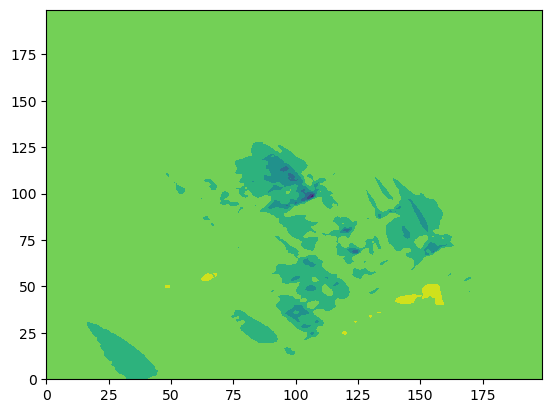

In [ ]:
plt.contourf(sn_sublim_3d.isel(Time=0).isel(snowpack_surface_layer=0))

In [25]:
# Extract d04 series at PEA using nearest native WRF grid point (robust for curvilinear grids)
lats, lons = wrf.latlon_coords(t2)

target_lat, target_lon = coords_PEA
distance2 = (lats - target_lat) ** 2 + (lons - target_lon) ** 2
j_idx, i_idx = np.unravel_index(
    np.nanargmin(wrf.to_np(distance2)),
    wrf.to_np(distance2).shape
)

print(
    f"d04 nearest grid point to PEA: (j,i)=({j_idx},{i_idx}), "
    f"lat={float(lats[j_idx, i_idx]):.5f}, lon={float(lons[j_idx, i_idx]):.5f}"
)

times_list = pd.to_datetime(t2.Time.values).tolist()

df_interp = pd.DataFrame({
    'Time': times_list,
    't2': np.asarray(wrf.to_np(t2[:, j_idx, i_idx]), dtype=float),
    'tskin': np.asarray(wrf.to_np(tsk[:, j_idx, i_idx]), dtype=float),
    'speed10': np.asarray(wrf.to_np(speed10[:, j_idx, i_idx]), dtype=float),
    'lh': np.asarray(wrf.to_np(lh[:, j_idx, i_idx]), dtype=float),
    'hfx': np.asarray(wrf.to_np(hfx[:, j_idx, i_idx]), dtype=float),
    'rh': np.asarray(wrf.to_np(rh[:, j_idx, i_idx]), dtype=float),
    'wind_dir': np.asarray(wrf.to_np(wind_dir[:, j_idx, i_idx]), dtype=float),
    'bs_qi': np.asarray(wrf.to_np(bs_qi[:, 0, j_idx, i_idx]), dtype=float)
})

print(f"Interpolated {len(df_interp)} time steps (d04)")
df_interp.index = df_interp.Time

d04 nearest grid point to PEA: (j,i)=(105,95), lat=-71.94900, lon=23.34985
Interpolated 577 time steps (d04)


In [26]:
# Extract d03 series at PEA using nearest native WRF grid point (robust for curvilinear grids)
lats_d03, lons_d03 = wrf.latlon_coords(t2_d03)

target_lat, target_lon = coords_PEA
distance2_d03 = (lats_d03 - target_lat) ** 2 + (lons_d03 - target_lon) ** 2
j_idx_d03, i_idx_d03 = np.unravel_index(
    np.nanargmin(wrf.to_np(distance2_d03)),
    wrf.to_np(distance2_d03).shape
)

print(
    f"d03 nearest grid point to PEA: (j,i)=({j_idx_d03},{i_idx_d03}), "
    f"lat={float(lats_d03[j_idx_d03, i_idx_d03]):.5f}, "
    f"lon={float(lons_d03[j_idx_d03, i_idx_d03]):.5f}"
)

times_list_d03 = pd.to_datetime(t2_d03.Time.values).tolist()

df_interp_d03 = pd.DataFrame({
    'Time': times_list_d03,
    't2': np.asarray(wrf.to_np(t2_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'tskin': np.asarray(wrf.to_np(tsk_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'speed10': np.asarray(wrf.to_np(speed10_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'lh': np.asarray(wrf.to_np(lh_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'hfx': np.asarray(wrf.to_np(hfx_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'rh': np.asarray(wrf.to_np(rh_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'wind_dir': np.asarray(wrf.to_np(wind_dir_d03[:, j_idx_d03, i_idx_d03]), dtype=float),
    'bs_qi': np.asarray(wrf.to_np(bs_qi_d03[:, 0, j_idx_d03, i_idx_d03]), dtype=float)
})

print(f"Interpolated {len(df_interp_d03)} time steps (d03)")
df_interp_d03.index = df_interp_d03.Time

d03 nearest grid point to PEA: (j,i)=(78,78), lat=-71.94542, lon=23.36136
Interpolated 577 time steps (d03)


In [16]:
t2_list

[243.9209220164829,
 243.8210433958642,
 243.63307995457242,
 243.55443499931113,
 243.38513267063914,
 243.60190525675256,
 246.43453768516855,
 247.39594649174026,
 248.20550135041586,
 251.3157100362028,
 251.66126626393822,
 251.60770913268527,
 251.99724992482163,
 252.085168448059,
 252.06433766933037,
 252.14786142203167,
 252.12964240136318,
 252.10676801236067,
 252.0778460364599,
 252.09550292186307,
 252.0889341465418,
 252.12119317893752,
 252.1360941796117,
 252.14467191302765,
 252.2367102333391,
 252.2282931373669,
 252.18934644265929,
 252.1727904247408,
 252.11683538803416,
 252.10085383373297,
 252.1857689442062,
 252.1748583244059,
 252.11951301119248,
 252.15923716089492,
 252.18990023761293,
 252.1243560497252,
 252.07181244816377,
 252.05081017693212,
 251.98610421723757,
 251.94521994251286,
 251.93499482521074,
 251.9078735005052,
 251.8349040018154,
 251.7700406002764,
 251.7054274844341,
 251.6422164816704,
 251.61651554248272,
 251.56377436643237,
 251.424974

In [17]:
t2_list_d03

[243.9209220164829,
 243.8210433958642,
 243.63307995457242,
 243.55443499931113,
 243.38513267063914,
 243.60190525675256,
 246.43453768516855,
 247.39594649174026,
 248.20550135041586,
 251.3157100362028,
 251.66126626393822,
 251.60770913268527,
 251.99724992482163,
 252.085168448059,
 252.06433766933037,
 252.14786142203167,
 252.12964240136318,
 252.10676801236067,
 252.0778460364599,
 252.09550292186307,
 252.0889341465418,
 252.12119317893752,
 252.1360941796117,
 252.14467191302765,
 252.2367102333391,
 252.2282931373669,
 252.18934644265929,
 252.1727904247408,
 252.11683538803416,
 252.10085383373297,
 252.1857689442062,
 252.1748583244059,
 252.11951301119248,
 252.15923716089492,
 252.18990023761293,
 252.1243560497252,
 252.07181244816377,
 252.05081017693212,
 251.98610421723757,
 251.94521994251286,
 251.93499482521074,
 251.9078735005052,
 251.8349040018154,
 251.7700406002764,
 251.7054274844341,
 251.6422164816704,
 251.61651554248272,
 251.56377436643237,
 251.424974

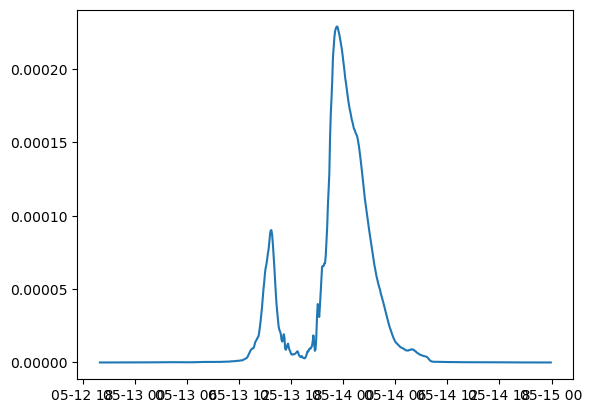

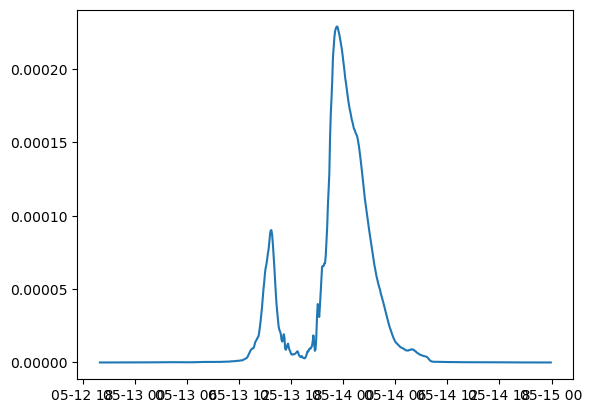

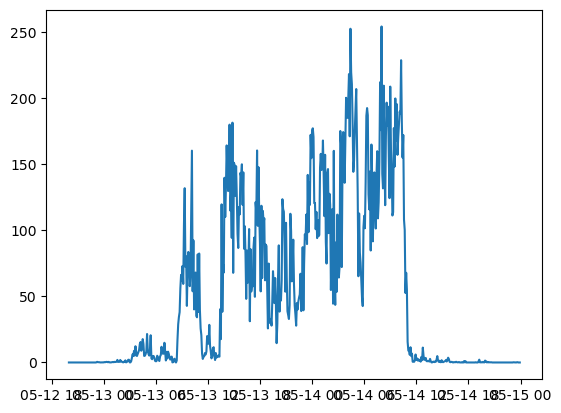

In [35]:
plt.plot(df_interp['bs_qi'])
plt.figure()
plt.plot(resample_with_threshold(data_obs['PF_FC4'][start:end], '5min', True, '5min', 80))


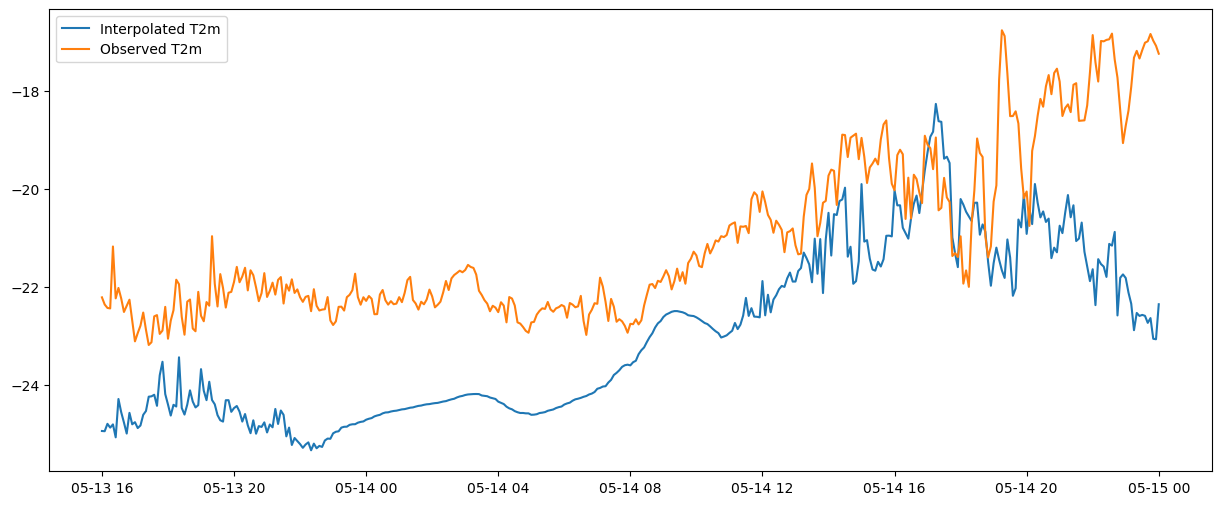

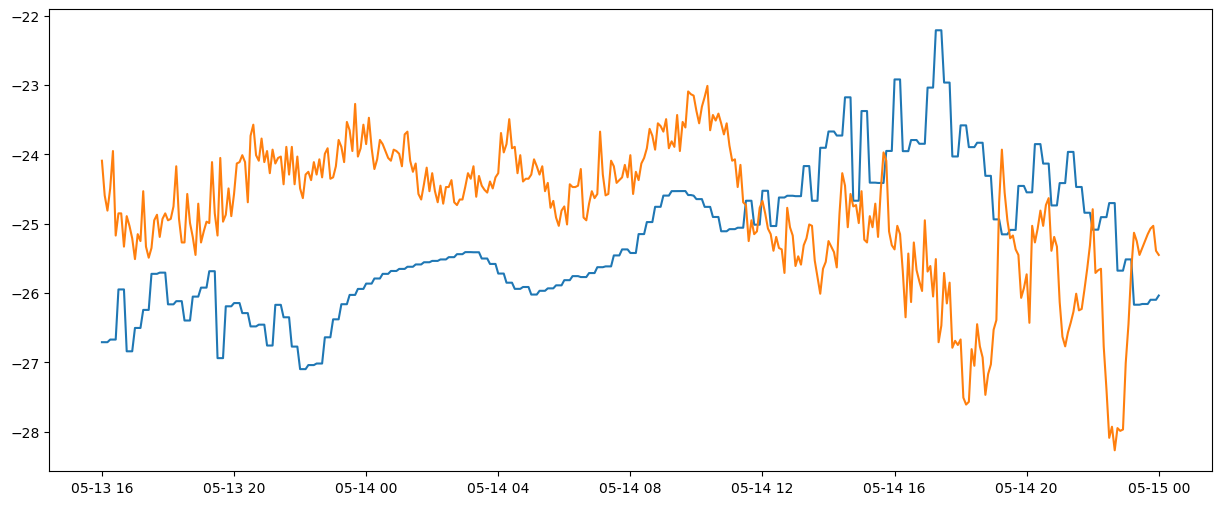

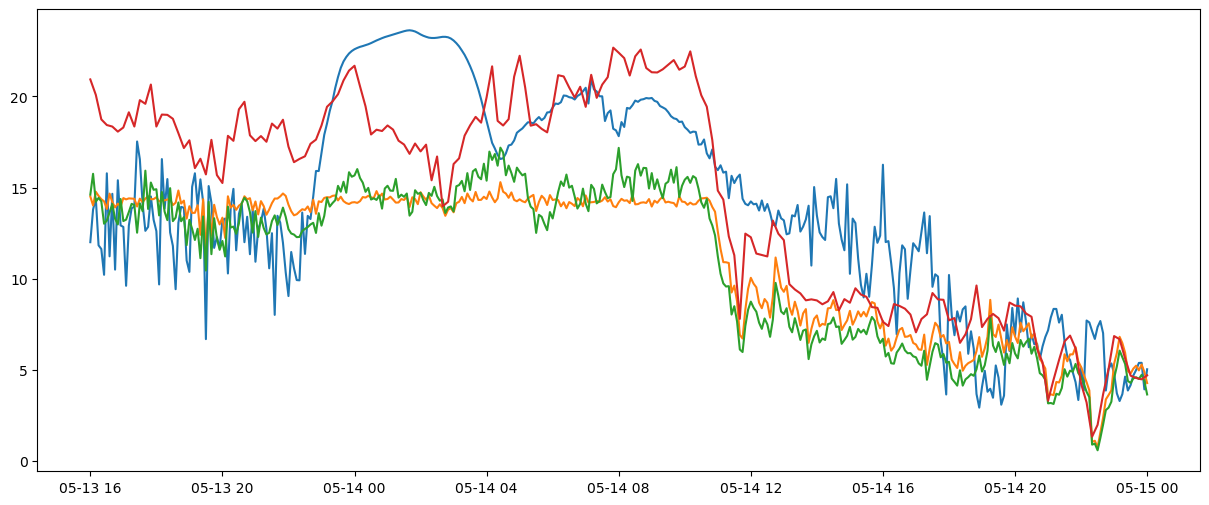

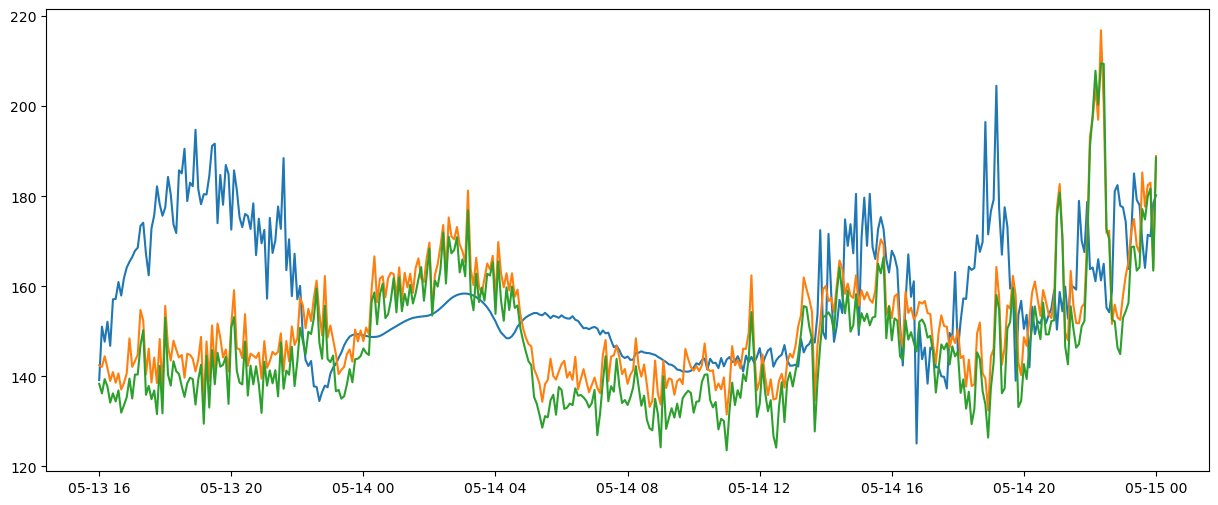

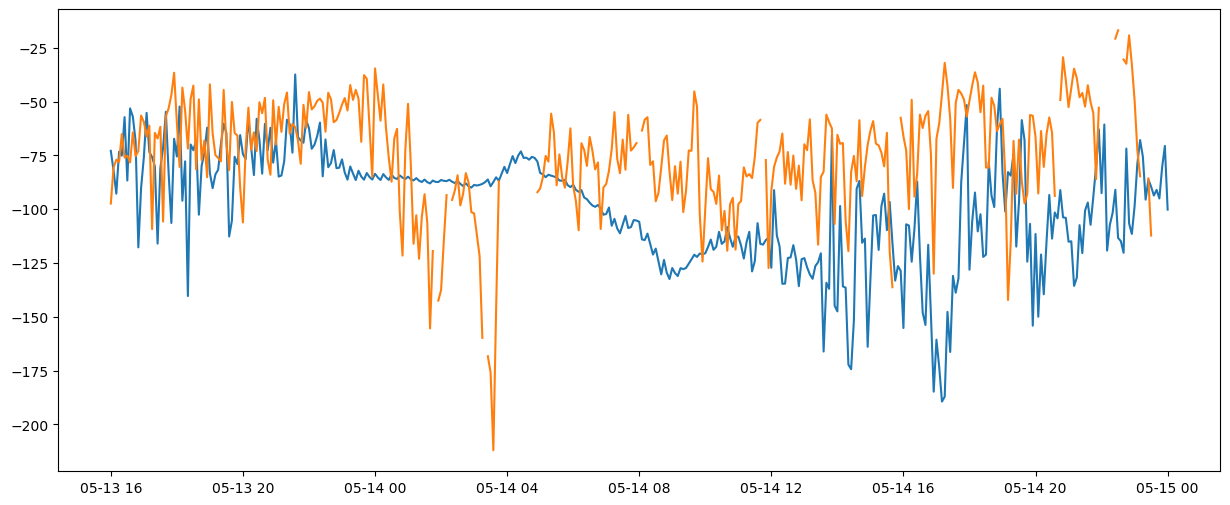

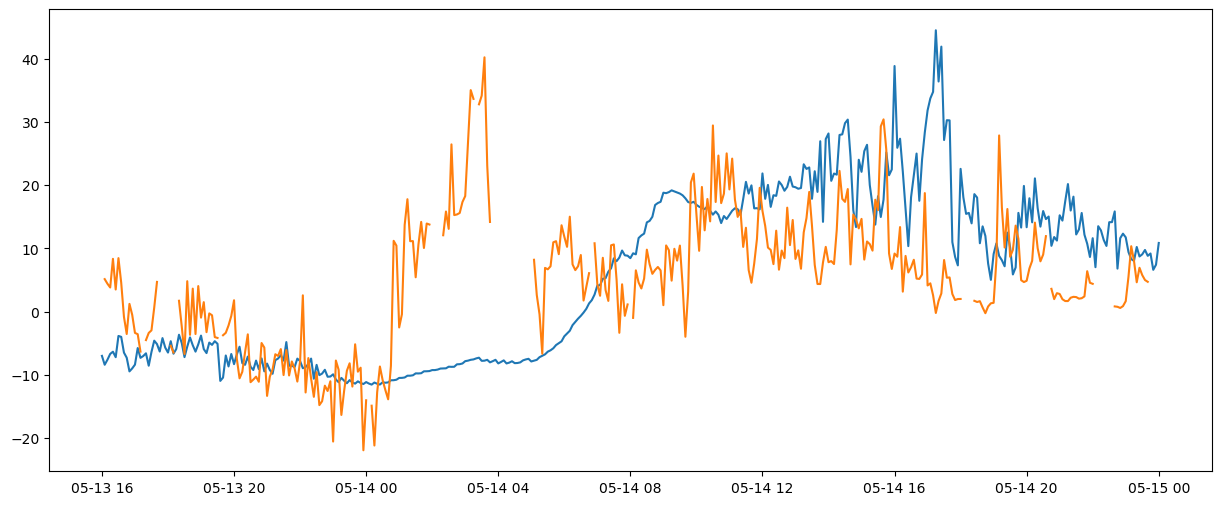

In [12]:
start=df_interp.Time.iloc[0]
end=df_interp.Time.iloc[-1]
plt.figure(figsize=(15,6))
plt.plot(df_interp['t2']-273.15, label='Interpolated T2m')
plt.plot(resample_with_threshold(data_obs['TA'][start:end], '5min', True, '5min', 80), label='Observed T2m')
plt.legend()
plt.figure(figsize=(15,6))
plt.plot(df_interp['tskin']-273.15, label='Interpolated ')
plt.plot(resample_with_threshold(data_obs['SFTempK'][start:end], '5min', True, '5min', 80)-273.15, label='Observed T2m')
plt.figure(figsize=(15,6))
plt.plot(df_interp['speed10'], label='Interpolated ')
plt.plot(resample_with_threshold(data_obs['WS1_Avg'][start:end], '5min', True, '5min', 80), label='Observed T2m')
plt.plot(resample_with_threshold(data_obs['WS2_Avg'][start:end], '5min', True, '5min', 80), label='Observed T2m')
plt.plot(resample_with_threshold(fluxes_16m['wind_speed'][start:end], '10min', True, '10min', 80), label='Observed T2m')
plt.figure(figsize=(15,6))
plt.plot(df_interp['wind_dir'], label='Interpolated ')
plt.plot(resample_with_threshold(data_obs['WD1'][start:end], '5min', True, '5min', 80), label='Observed T2m')
plt.plot(resample_with_threshold(data_obs['WD2'][start:end], '5min', True, '5min', 80), label='Observed T2m')
plt.figure(figsize=(15,6))
plt.plot(df_interp['hfx'], label='Interpolated ')
plt.plot(resample_with_threshold(fluxes_SFC['H'][start:end], '5min', True, '5min', 80), label='Observed T2m')
plt.figure(figsize=(15,6))
plt.plot(df_interp['lh'], label='Interpolated ')
plt.plot(resample_with_threshold(fluxes_SFC['LE'][start:end], '5min', True, '5min', 80), label='Observed T2m')


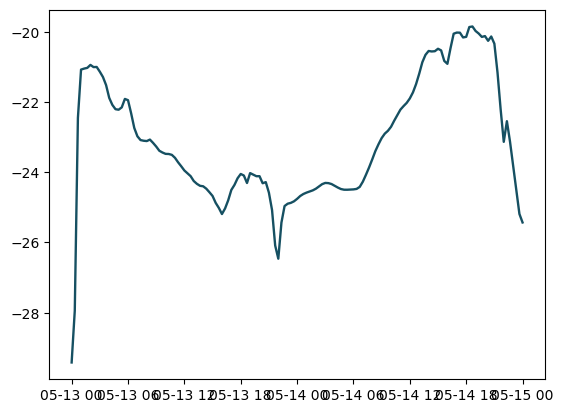

In [13]:
plt.plot(df_interp_mean['t2'] - 273.15, label='CRYOWRF d04 T$_{2m}$', linewidth=1.7, color=color_d04)


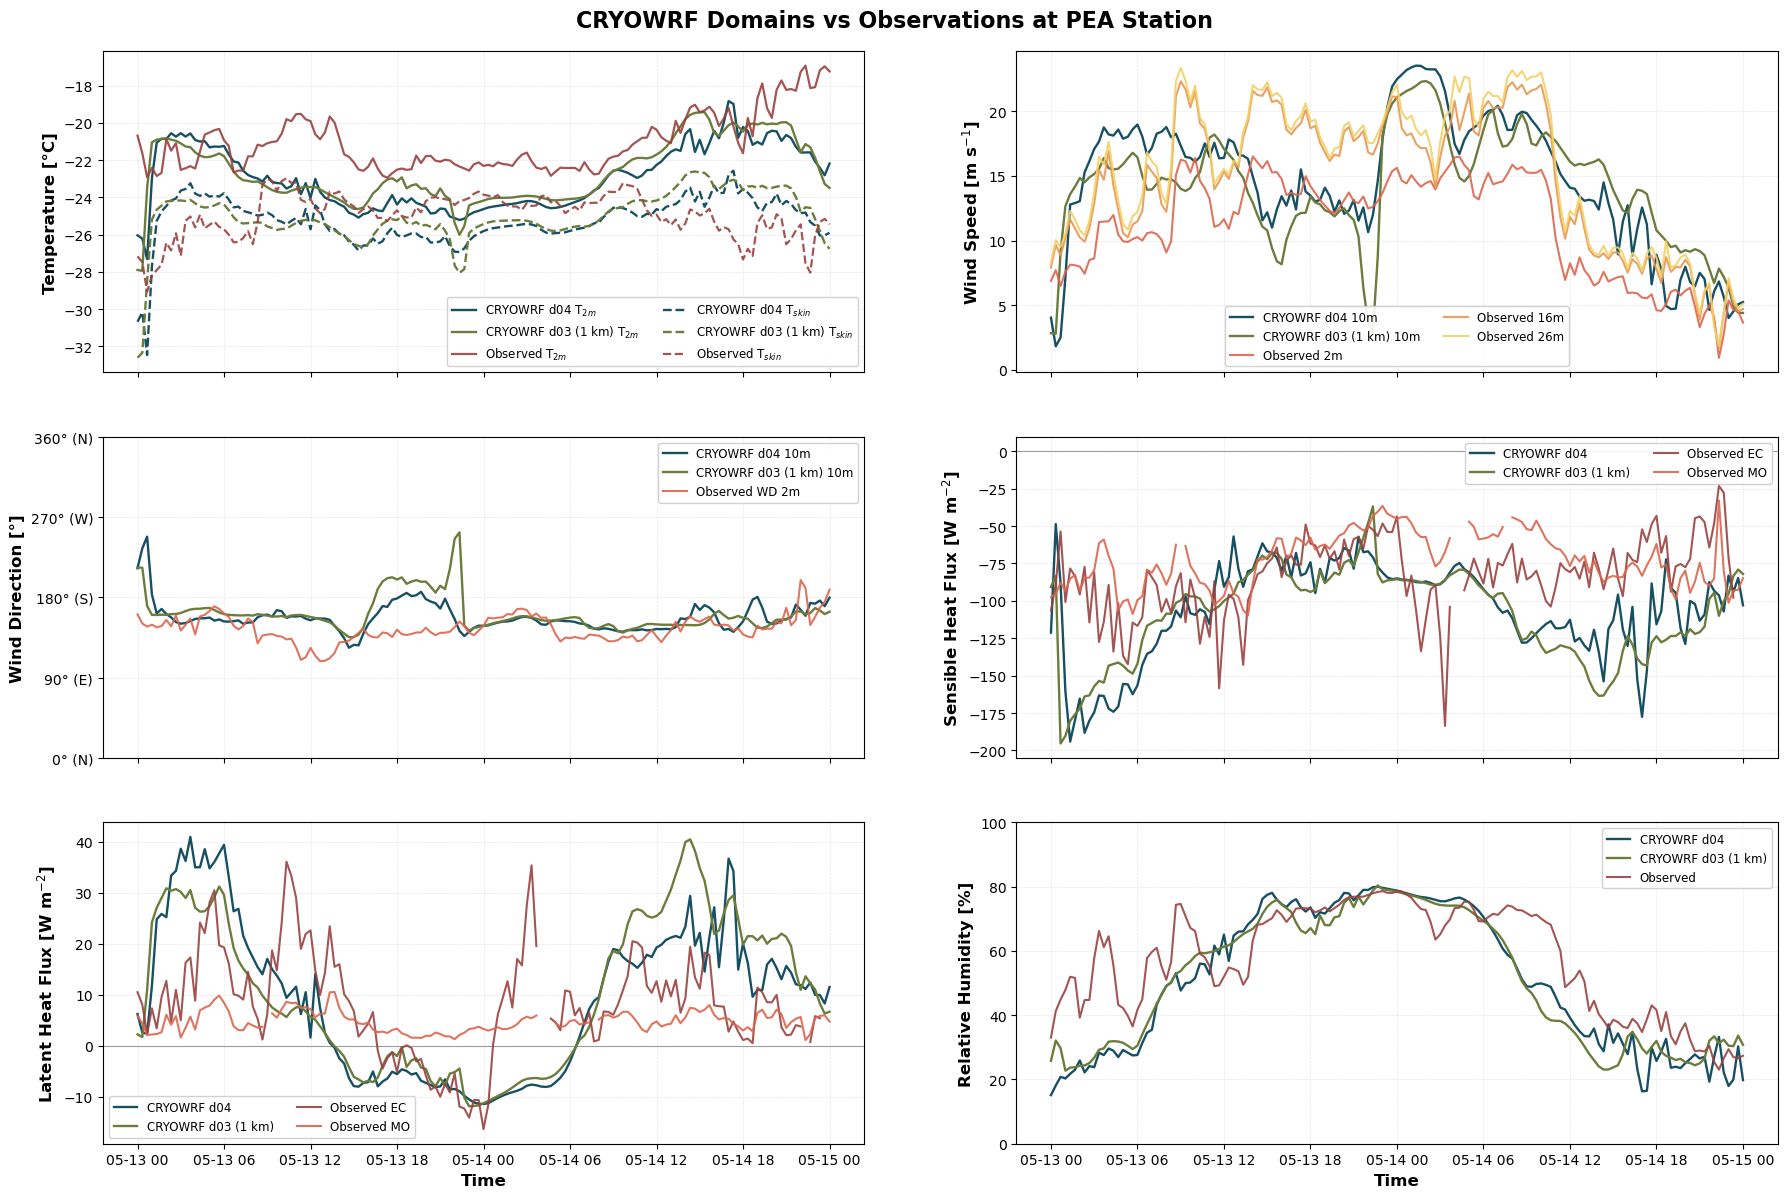

In [27]:
import cmcrameri.cm as cmc

# Use common timerange between d04 and d03 model outputs
start = max(df_interp.Time.iloc[0], df_interp_d03.Time.iloc[0])
end = min(df_interp.Time.iloc[-1], df_interp_d03.Time.iloc[-1])

avg_interval = '20min'
avg_interpolate = '15min'

# Resample model data to same interval as comparison
df_interp_mean = df_interp.resample(avg_interval).mean().loc[start:end]
df_interp_d03_mean = df_interp_d03.resample(avg_interval).mean().loc[start:end]

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('CRYOWRF Domains vs Observations at PEA Station', fontsize=16, fontweight='bold', y=0.995)

# Color design:
# - Models (d04/d03) use cool colors from same family
# - Observations use warm/contrasting colors
model_colors = cmc.batlow(np.linspace(0.18, 0.45, 2))
obs_colors = cmc.lajolla(np.linspace(0.35, 0.85, 4))

color_d04 = model_colors[0]
color_d03 = model_colors[1]
color_obs1 = obs_colors[0]
color_obs2 = obs_colors[1]
color_obs3 = obs_colors[2]
color_obs4 = obs_colors[3]

# Temperature (T2m and Tskin)
ax = axes[0, 0]
ax.plot(df_interp_mean['t2'] - 273.15, label='CRYOWRF d04 T$_{2m}$', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['t2'] - 273.15, label='CRYOWRF d03 (1 km) T$_{2m}$', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(data_obs['TA'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed T$_{2m}$', linewidth=1.6, color=color_obs1, alpha=0.9
)

ax.plot(df_interp_mean['tskin'] - 273.15, label='CRYOWRF d04 T$_{skin}$', linewidth=1.7, linestyle='--', color=color_d04)
ax.plot(df_interp_d03_mean['tskin'] - 273.15, label='CRYOWRF d03 (1 km) T$_{skin}$', linewidth=1.7, linestyle='--', color=color_d03)
ax.plot(
    resample_with_threshold(data_obs['SFTempK'][start:end], avg_interval, True, avg_interpolate, 80) - 273.15,
    label='Observed T$_{skin}$', linewidth=1.6, linestyle='--', color=color_obs1, alpha=0.9
)
ax.set_ylabel('Temperature [°C]', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xticklabels([])

# Wind Speed
ax = axes[0, 1]
ax.plot(df_interp_mean['speed10'], label='CRYOWRF d04 10m', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['speed10'], label='CRYOWRF d03 (1 km) 10m', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(data_obs['WS2_Avg'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed 2m', linewidth=1.5, color=color_obs2, alpha=0.9
)
ax.plot(
    resample_with_threshold(fluxes_16m['wind_speed'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed 16m', linewidth=1.5, color=color_obs3, alpha=0.9
)
ax.plot(
    resample_with_threshold(fluxes_26m['wind_speed'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed 26m', linewidth=1.5, color=color_obs4, alpha=0.9
)
ax.set_ylabel('Wind Speed [m s$^{-1}$]', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xticklabels([])

# Wind Direction
ax = axes[1, 0]
ax.plot(df_interp_mean['wind_dir'], label='CRYOWRF d04 10m', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['wind_dir'], label='CRYOWRF d03 (1 km) 10m', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(data_obs['WD2'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed WD 2m', linewidth=1.5, color=color_obs2, alpha=0.9
)
ax.set_ylabel('Wind Direction [°]', fontsize=12, fontweight='bold')
ax.set_ylim(0, 360)
ax.set_yticks([0, 90, 180, 270, 360])
ax.set_yticklabels(['0° (N)', '90° (E)', '180° (S)', '270° (W)', '360° (N)'])
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xticklabels([])

# Sensible Heat Flux
ax = axes[1, 1]
ax.plot(df_interp_mean['hfx'], label='CRYOWRF d04', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['hfx'], label='CRYOWRF d03 (1 km)', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(fluxes_SFC['H'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed EC', linewidth=1.5, color=color_obs1, alpha=0.9
)
ax.plot(
    resample_with_threshold(MO_data['H'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed MO', linewidth=1.5, color=color_obs2, alpha=0.9
)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.4, zorder=1)
ax.set_ylabel('Sensible Heat Flux [W m$^{-2}$]', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xticklabels([])

# Latent Heat Flux
ax = axes[2, 0]
ax.plot(df_interp_mean['lh'], label='CRYOWRF d04', linewidth=1.7, color=color_d04)
ax.plot(df_interp_d03_mean['lh'], label='CRYOWRF d03 (1 km)', linewidth=1.7, color=color_d03)
ax.plot(
    resample_with_threshold(fluxes_SFC['LE'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed EC', linewidth=1.5, color=color_obs1, alpha=0.9
)
ax.plot(
    resample_with_threshold(MO_data['LE'][start:end], avg_interval, True, avg_interpolate, 80),
    label='Observed MO', linewidth=1.5, color=color_obs2, alpha=0.9
)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.4, zorder=1)
ax.set_ylabel('Latent Heat Flux [W m$^{-2}$]', fontsize=12, fontweight='bold')
ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Relative Humidity
ax = axes[2, 1]
has_rh = False
if 'rh' in df_interp_mean.columns:
    ax.plot(df_interp_mean['rh'], label='CRYOWRF d04', linewidth=1.7, color=color_d04)
    has_rh = True
if 'rh' in df_interp_d03_mean.columns:
    ax.plot(df_interp_d03_mean['rh'], label='CRYOWRF d03 (1 km)', linewidth=1.7, color=color_d03)
    has_rh = True
if 'RH' in data_obs.columns:
    ax.plot(
        resample_with_threshold(data_obs['RH'][start:end], avg_interval, True, avg_interpolate, 80),
        label='Observed', linewidth=1.5, color=color_obs1, alpha=0.9
    )
    has_rh = True

if has_rh:
    ax.set_ylabel('Relative Humidity [%]', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.legend(loc='best', frameon=True, fontsize=8.5, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
else:
    ax.axis('off')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.96, hspace=0.2, wspace=0.2)
plt.show()

In [36]:
df_interp.wind_dir.mean()

157.35511445126812

In [75]:

class CrossSectionPlotter:
    def __init__(self, wrflist, theta, z, speed, speed10, u10, v10, u, v, w, tke, ter, lh, hfx, cldfra, cross_start, cross_end, gridpoints, cross_sec, event):
        self.wrflist = wrflist
        self.theta = theta
        self.z = z
        self.speed = speed
        self.u = u
        self.v = v
        self.w = w
        self.speed10 = speed10
        self.u10 = u10
        self.v10 = v10

        self.tke = tke
        self.ter = ter
        self.lh = lh
        self.hfx = hfx
        self.cldfra = cldfra
        self.cross_start = cross_start
        self.cross_end = cross_end
        self.gridpoints = gridpoints
        self.cross_sec = cross_sec
        self.event = event

        # Define cross-sections
        self.define_cross_sections()

        # Set matplotlib parameters
        plt.rcParams['font.size'] = 15
        plt.rcParams['lines.linewidth'] = 2

        # Calculate xs and ys
        self.xs = wrf.pairs_to_latlon(wrf.to_np(self.th_vert[:,:,:].coords['xy_loc']))[0]
        self.ys = wrf.pairs_to_latlon(wrf.to_np(self.w_cross[:,:,:].coords['xy_loc']))[1]

    def define_cross_sections(self):
        self.lats, self.lons = wrf.latlon_coords(self.ter)

        self.th_vert = wrf.vertcross(self.theta.isel(bottom_top=np.arange(0,16)), self.z.isel(bottom_top=np.arange(0,16)), wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)
        self.th_vert.attrs["description"] = "Pot temperature cross section"
        self.th_vert.attrs["units"] = "K"

        self.u_vert = wrf.vertcross(self.speed.isel(bottom_top=np.arange(0,16)), self.z.isel(bottom_top=np.arange(0,16)), wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)
        self.u_vert.attrs["description"] = "Wind speed cross section"
        self.u_vert.attrs["units"] = "K"

        self.u_cross = wrf.vertcross(self.u.isel(bottom_top=np.arange(0,16)), self.z.isel(bottom_top=np.arange(0,16)), wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)
        self.u_cross.attrs.update(self.u_cross.attrs)
        self.u_cross.attrs["description"] = "u-wind cross section"
        self.u_cross.attrs["units"] = "m s-1"

        self.v_cross = wrf.vertcross(self.v.isel(bottom_top=np.arange(0,16)), self.z.isel(bottom_top=np.arange(0,16)), wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)
        self.v_cross.attrs.update(self.v_cross.attrs)
        self.v_cross.attrs["description"] = "v-wind cross section"
        self.v_cross.attrs["units"] = "m s-1"

        self.w_cross = wrf.vertcross(self.w.isel(bottom_top=np.arange(0,16)), self.z.isel(bottom_top=np.arange(0,16)), wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)
        self.w_cross.attrs.update(self.v_cross.attrs)
        self.w_cross.attrs["description"] = "v-wind cross section"
        self.w_cross.attrs["units"] = "m s-1"

        self.h_wind_cross = self.rotate_u_v_cross(self.u_cross, self.v_cross)
        self.h_wind_cross = xr.DataArray(self.h_wind_cross)
        self.h_wind_cross.attrs.update(self.v_cross.attrs)
        self.h_wind_cross.attrs["description"] = "horizontal-wind cross section"
        self.h_wind_cross.attrs["units"] = "m s-1"

        self.h_wind_perp = self.rotate_u_v_perpendicular(self.u_cross, self.v_cross)
        self.h_wind_perp = xr.DataArray(self.h_wind_perp)
        self.h_wind_perp.attrs.update(self.v_cross.attrs)
        self.h_wind_perp.attrs["description"] = "horizontal-wind perpendicular to cross section"
        self.h_wind_perp.attrs["units"] = "m s-1"

        self.tke_cross = wrf.vertcross(self.tke.isel(bottom_top=np.arange(0,16)), self.z.isel(bottom_top=np.arange(0,16)), wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)
        self.tke_cross.attrs.update(self.tke_cross.attrs)
        self.tke_cross.attrs["description"] = "TKE cross section"
        self.tke_cross.attrs["units"] = "m2 s-2"

        self.clfra_vert = wrf.vertcross(self.cldfra.isel(bottom_top=np.arange(0,16)), self.z.isel(bottom_top=np.arange(0,16)), wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)
        self.clfra_vert.attrs.update(self.clfra_vert.attrs)
        self.clfra_vert.attrs["description"] = "Cloud fraction cross section"
        self.clfra_vert.attrs["units"] = "1"

        self.ter_cross = wrf.interpline(self.ter, wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)
        self.lh_cross = wrf.interpline(self.lh, wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)
        self.hfx_cross = wrf.interpline(self.hfx, wrfin=self.wrflist, start_point=self.cross_start, end_point=self.cross_end, latlon=True, meta=True)

    def rotate_u_v_cross(self, u_cross, v_cross):
        # Get the distance of the grid points in x and y directions
        x_coords = np.array([pair.x for pair in wrf.to_np(u_cross.coords["xy_loc"])])
        y_coords = np.array([pair.y for pair in wrf.to_np(u_cross.coords["xy_loc"])])
        distX = (x_coords[-1] - x_coords[1]) * u_cross.attrs['projection'].dx
        distY = (y_coords[-1] - y_coords[1]) * v_cross.attrs['projection'].dy
        distXun = distX / np.sqrt(distX**2 + distY**2)  # unitary vector for LN
        distYun = distY / np.sqrt(distX**2 + distY**2)  # unitary vector for LT
        Hwind_cross = np.array(distXun * u_cross + distYun * v_cross)
        return Hwind_cross

    def rotate_u_v_perpendicular(self, u_cross, v_cross):
        # Get the distance of the grid points in x and y directions
        x_coords = np.array([pair.x for pair in wrf.to_np(u_cross.coords["xy_loc"])])
        y_coords = np.array([pair.y for pair in wrf.to_np(u_cross.coords["xy_loc"])])
        # Calculate distances in x and y directions
        distX = (x_coords[-1] - x_coords[1]) * u_cross.attrs['projection'].dx
        distY = (y_coords[-1] - y_coords[1]) * v_cross.attrs['projection'].dy
        # Calculate unitary vectors for the cross-section line
        distXun = distX / np.sqrt(distX**2 + distY**2)  # unitary vector for LN
        distYun = distY / np.sqrt(distX**2 + distY**2)  # unitary vector for LT
        # Calculate unitary vectors for the perpendicular direction
        distXun_perp = -distYun  # unitary vector for LN perpendicular
        distYun_perp = distXun   # unitary vector for LT perpendicular
        # Rotate wind components to the perpendicular coordinate system
        Hwind_perpendicular = np.array(distXun_perp * u_cross + distYun_perp * v_cross)
        return Hwind_perpendicular

    def plot_cross_section(self, itime):
        dt_5min = 3
        time_str = pd.to_datetime(self.th_vert.Time.values[itime]+pd.Timedelta('1h')).strftime('%Y-%m-%d_%H:%M:%S')
        time_str_day=pd.to_datetime(self.th_vert.Time.values[-12]).strftime('%Y-%m-%d')
        speed10_mean_ = self.speed10.isel(Time=np.arange(itime, itime+dt_5min)).mean('Time')
        u10_mean_ = self.u10.isel(Time=np.arange(itime, itime+dt_5min)).mean('Time')
        v10_mean_ = self.v10.isel(Time=np.arange(itime, itime+dt_5min)).mean('Time')
        th_vert_mean_ = (self.th_vert.isel(Time=np.arange(itime, itime+dt_5min)) - 273).mean('Time')
        u_vert_mean_ = self.u_vert.isel(Time=np.arange(itime, itime+dt_5min)).mean('Time')
        hfx_mean_ = self.hfx_cross.isel(Time=np.arange(itime, itime+dt_5min)).mean('Time')

        hfx_mean_tot= self.hfx_cross.sel(Time=time_str_day).mean('Time')
        lh_mean_ = self.lh_cross.isel(Time=np.arange(itime, itime+dt_5min)).mean('Time')
        lh_mean_tot= self.lh_cross.sel(Time=time_str_day).mean('Time')
        w_cross_mean_ = self.w_cross.isel(Time=np.arange(itime, itime+dt_5min)).mean('Time')
        cldfra_mean_ = self.clfra_vert.isel(Time=np.arange(itime, itime+dt_5min)).mean('Time')
        
        # Align time values between th_vert and tke_cross
        common_times = np.intersect1d(self.th_vert.Time.values[itime:itime+dt_5min], self.tke_cross.Time.values)

        tke_cross_mean_ = self.tke_cross.sel(Time=common_times).mean('Time')
        tke_cross_mean_ = self.tke_cross.sel(Time=self.th_vert.Time.values[itime:itime+dt_5min]).mean('Time')
        
        h_wind_cross_mean_ = self.h_wind_cross.isel(dim_0=np.arange(itime, itime+dt_5min)).mean('dim_0')
        h_wind_perp_mean_ = self.h_wind_perp.isel(dim_0=np.arange(itime, itime+dt_5min)).mean('dim_0')

        fig = plt.figure(figsize=(26, 20))
        gs = gridspec.GridSpec(4, 3)
        plt.tight_layout()

        ### PLOT SMALL WIND MAP ###
        ax = fig.add_subplot(gs[1, 0], projection=ccrs.NorthPolarStereo(central_longitude=9.8))
        ax.set_extent([np.min(self.lons[self.gridpoints, self.gridpoints]), np.max(self.lons[self.gridpoints, self.gridpoints]), np.min(self.lats[self.gridpoints, self.gridpoints]), np.max(self.lats[self.gridpoints, self.gridpoints])], ccrs.PlateCarree())
        gls = ax.gridlines(draw_labels=True, linewidth=.5, color='gray', alpha=0.5, linestyle='--')
        gls.top_labels = False
        gls.xlabel_style = {'size': 12}
        gls.right_labels = True
        CSb = ax.contour(wrf.to_np(self.lons)[self.gridpoints, self.gridpoints], wrf.to_np(self.lats)[self.gridpoints, self.gridpoints], wrf.to_np(self.ter[self.gridpoints, self.gridpoints]), np.arange(800, 4000, 500), cmap="gray", transform=ccrs.PlateCarree(), extend="both")
        CS = ax.contourf(wrf.to_np(self.lons)[self.gridpoints, self.gridpoints], wrf.to_np(self.lats)[self.gridpoints, self.gridpoints], wrf.to_np(speed10_mean_[self.gridpoints, self.gridpoints]), np.arange(0, 18, 1), cmap="YlGn", transform=ccrs.PlateCarree(), extend="both")
        intervalx = 7
        intervaly = 7
        widthfactor = 0.004
        scalefactor = 100
        CSd = ax.quiver(wrf.to_np(self.lons[self.gridpoints, self.gridpoints])[::intervalx, ::intervaly], wrf.to_np(self.lats[self.gridpoints, self.gridpoints])[::intervalx, ::intervaly], wrf.to_np(u10_mean_[self.gridpoints, self.gridpoints])[::intervalx, ::intervaly], wrf.to_np(v10_mean_[self.gridpoints, self.gridpoints])[::intervalx, ::intervaly], color='k', width=widthfactor, scale=scalefactor, transform=ccrs.PlateCarree(), zorder=20)

        cbar = plt.colorbar(CS, ax=ax)
        cbar.set_label(r'Wind speed [$ms^{-1}$] at 10m', fontsize=12)
        # plt.scatter(self.WFJ_latlon[1], self.WFJ_latlon[0], color='red', transform=ccrs.PlateCarree())
        # plt.scatter(self.GOT_latlon[1], self.GOT_latlon[0], color='blue', transform=ccrs.PlateCarree())

        CSc = ax.plot([self.cross_start.lon, self.cross_end.lon], [self.cross_start.lat, self.cross_end.lat], color='red', transform=ccrs.PlateCarree())

        ### PLOT CROSS THETA ###
        ax = fig.add_subplot(gs[0, 1:])
        minval = (self.th_vert.min()-273+3).values
        maxval = (self.th_vert.max()-273-3).values
        # if self.cross_sec == 'cross_sec6' and self.event == 'SOUTH':
        #     minval = 20
        x_axis = self.xs if self.cross_sec == 'cross_sec5' or self.cross_sec == 'cross_sec6' else self.ys
        P_theta = ax.contourf(x_axis, th_vert_mean_[:, :].coords["vertical"], th_vert_mean_[:, :], cmap=cmc.glasgow.reversed(), vmin=minval, vmax=maxval, levels=40)
        P_cloud = ax.contour(x_axis, th_vert_mean_[:, :].coords["vertical"], cldfra_mean_[:, :], levels=3, alpha=0.5, cmap="Greys")
        ax.clabel(P_cloud, inline=True, fontsize=10, fmt='%1.1f')
        ax.fill_between(x_axis, 0, self.ter_cross, color='saddlebrown')
        cbar = plt.colorbar(P_theta, ax=ax, location='top', shrink=0.3, pad=0.025, ticks=np.linspace(int(minval), int(maxval), 6))
        cbar.set_label('Theta $[^oC]$', fontsize=13)

        P_theta.set_clim(minval, maxval)
        ax.set_ylabel('Elevation [m]')


        ax.set_ylim(1400, 3400)
        if self.cross_sec == 'cross_sec3':
            ax.set_ylim(1200, 3000)
        if self.cross_sec == 'cross_sec5' or self.cross_sec == 'cross_sec6':
            ax.set_ylim(900, 4000)
        ### PLOT CROSS WIND ###
        interval = 4
        intervalx = 4
        intervaly = 4
        widthfactor = 0.002
        scalefactor = 300

        if self.cross_sec == 'cross_sec5' or self.cross_sec == 'cross_sec6':
            intervalx = 7
            intervaly = 7
            widthfactor = 0.002
            scalefactor = 300

        ax = fig.add_subplot(gs[1, 1:])
        P_wind = ax.pcolormesh(x_axis, u_vert_mean_[:, :].coords["vertical"], u_vert_mean_[:, :], cmap="YlGn", shading="gouraud", vmin=0, vmax=20)
        ax.fill_between(x_axis, 0, self.ter_cross, color='saddlebrown')
        ax.quiver(x_axis[::intervalx], u_vert_mean_[:, :].coords["vertical"][::intervaly], wrf.to_np(h_wind_cross_mean_[::intervaly, ::intervalx]), wrf.to_np(w_cross_mean_[::intervaly, ::intervalx]), color='k', width=widthfactor, scale=scalefactor, zorder=20)
        P_perpwind = ax.contour(x_axis, tke_cross_mean_[:, :].coords["vertical"], h_wind_perp_mean_[:, :], levels=10)
        ax.clabel(P_perpwind, inline=True, fontsize=10, fmt='%1.1f')
        cbar = plt.colorbar(P_wind, ax=ax, location='top', shrink=0.3, pad=0.025, ticks=np.arange(0, 20, 2))
        cbar.set_label('Wind speed $[m s^{-1}]$', fontsize=13)
        ax.set_ylim(1400, 3400)
        ax.set_ylabel('Elevation [m]')

        if self.cross_sec == 'cross_sec3':
            ax.set_ylim(1200, 3000)
        if self.cross_sec == 'cross_sec5' or self.cross_sec == 'cross_sec6':   
            ax.set_ylim(900, 4000)

        ### PLOT CROSS TKE ###
        ax = fig.add_subplot(gs[2, 1:])
        minval = self.tke_cross.min().item()
        maxval = self.tke_cross.max().item()
        # print(minval, maxval, self.tke_cross.min().values)
        P_tke = ax.contourf(x_axis, tke_cross_mean_[:, :].coords["vertical"], tke_cross_mean_[:, :], cmap=cmc.roma, vmin=minval, vmax=maxval, levels=40)
        ax.fill_between(x_axis, 0, self.ter_cross, color='saddlebrown')
        cbar = plt.colorbar(P_tke, ax=ax, location='top', shrink=0.3, pad=0.025, ticks=np.linspace(int(minval), int(maxval), 6))
        cbar.set_label('TKE [m²s⁻²]', fontsize=13)
        P_tke.set_clim(minval, maxval)
        ax.set_ylim(1400, 3400)
        ax.set_ylabel('Elevation [m]')
        if self.cross_sec == 'cross_sec3':
            ax.set_ylim(1200, 3000)
        if self.cross_sec == 'cross_sec5' or self.cross_sec == 'cross_sec6':
            ax.set_ylim(900, 4000)
            maxval=7
        P_tke.set_clim(minval, maxval)


        # ### PLOT CROSS RICHARDSON ###
        # ax = fig.add_subplot(gs[2, 1:])
        # minval = self.tke_cross.min().item()
        # maxval = self.tke_cross.max().item()
        # P_tke = ax.contourf(x_axis, tke_cross_mean_[:, :].coords["vertical"], tke_cross_mean_[:, :], cmap=cmc.roma, vmin=minval, vmax=maxval, levels=40)
        # ax.fill_between(x_axis, 0, self.ter_cross, color='saddlebrown')
        # cbar = plt.colorbar(P_tke, ax=ax, location='top', shrink=0.3, pad=0.025, ticks=np.linspace(int(minval), int(maxval), 6))
        # cbar.set_label('TKE [m²s⁻²]', fontsize=13)
        # ax.set_ylim(1400, 3400)
        # ax.set_ylabel('Elevation [m]')
        # if self.cross_sec == 'cross_sec3':
        #     ax.set_ylim(1200, 3000)
        # if self.cross_sec == 'cross_sec5' or self.cross_sec == 'cross_sec6':
        #     ax.set_ylim(900, 4000)
        #     maxval=7
        # P_tke.set_clim(minval, maxval)



        ### PLOT TURBULENT FLUXES ###
        ax = fig.add_subplot(gs[3, 1:])
        P_flux = plt.plot(x_axis, hfx_mean_, label='Sensible heat flux', color='darkred')
        plt.plot(x_axis, hfx_mean_tot, color='darkred', linestyle='--', alpha=0.7, label='24h average')
        P_flux = plt.plot(x_axis, lh_mean_, label='Latent heat flux', color='darkblue')
        plt.plot(x_axis, lh_mean_tot, color='darkblue', linestyle='--', alpha=0.7, label='24h average')
        ax.set_ylabel(r'[Wm⁻²]')
        plt.ylim(-240, 140)
        if self.event == 'NORTH':
            plt.ylim(-110, 80)
        ax.legend(frameon=False)
        plt.xlim(x_axis[0], x_axis[-1])
        number = re.search(r'\d+', self.cross_sec).group()
        plt.suptitle(f'CS{number} {self.event} Time = {time_str}', fontsize=21, y=0.93)
        save_path = f'/capstor/scratch/cscs/rengbers/figures/{self.cross_sec}_{self.event}_RAD/{self.cross_sec}_{time_str}.pdf'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved {save_path}')
        # plt.show()
        return hfx_mean_, lh_mean_, speed10_mean_

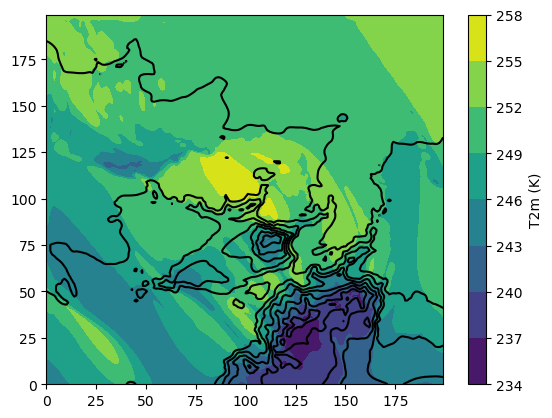

In [32]:
p=plt.contourf(t2.isel(Time=-1))
plt.contour(ter, levels=10, colors='k')
plt.colorbar(p, label='T2m (K)')

In [8]:
def create_simple_cross_section(wrflist, center_lat, center_lon, direction_deg, length_km=50, 
                                 theta=None, speed=None, bs_qi=None, sn_qs=None, sn_c_height=None, 
                                 u=None, v=None, w=None, z=None, ter=None, time_idx=0):
    """
    Create a simple cross-section through a WRF domain.
    
    Parameters:
    -----------
    wrflist : list
        List of WRF netCDF file handles
    center_lat : float
        Latitude of cross-section center point
    center_lon : float
        Longitude of cross-section center point
    direction_deg : float
        Direction of cross-section in degrees (0=North, 90=East, 180=South, 270=West)
        Meteorological convention: clockwise from North
    length_km : float
        Total length of cross-section in km (default: 50)
    theta : xr.DataArray
        Potential temperature (optional)
    speed : xr.DataArray
        Wind speed (optional)
    bs_qi : xr.DataArray
        Blowing snow ice mixing ratio (optional)
    sn_qs : xr.DataArray
        Snow saltation mixing ratio (optional)
    sn_c_height : xr.DataArray
        Snow saltation height coordinate (optional)
    u : xr.DataArray
        U-wind component (optional)
    v : xr.DataArray
        V-wind component (optional)
    w : xr.DataArray
        W-wind component (optional)
    z : xr.DataArray
        Height field for vertical interpolation
    ter : xr.DataArray
        Terrain height
    time_idx : int
        Time index to extract (default: 0)
    
    Returns:
    --------
    dict : Dictionary containing cross-section data with keys:
        - 'theta_cross': temperature cross-section (if theta provided)
        - 'speed_cross': wind speed cross-section (if speed provided)
        - 'bs_qi_cross': blowing snow cross-section (if bs_qi provided)
        - 'sn_qs_cross': saltation cross-section (if sn_qs provided)
        - 'u_cross': u-wind cross-section (if u provided)
        - 'v_cross': v-wind cross-section (if v provided)
        - 'w_cross': w-wind cross-section (if w provided)
        - 'h_wind_cross': horizontal wind along cross-section
        - 'ter_cross': terrain along cross-section
        - 'distance': distance along cross-section
        - 'start_point': CoordPair for start
        - 'end_point': CoordPair for end
    """
    from wrf import CoordPair
    
    # Calculate start and end points
    # Convert meteorological direction (clockwise from North) to math direction (counter-clockwise from East)
    # Meteorological: 0°=N, 90°=E, 180°=S, 270°=W
    # Mathematical: 0°=E, 90°=N, 180°=W, 270°=S
    math_direction_deg = 90 - direction_deg
    direction_rad = np.deg2rad(math_direction_deg)
    
    # Calculate half-length offset in degrees (approximate)
    half_length_deg = (length_km / 2) / 111  # rough conversion: 1 degree ≈ 111 km
    
    # Calculate start and end coordinates
    # Math convention: x=longitude, y=latitude
    start_lat = center_lat - half_length_deg * np.sin(direction_rad)
    start_lon = center_lon - half_length_deg * np.cos(direction_rad)
    
    end_lat = center_lat + half_length_deg * np.sin(direction_rad)
    end_lon = center_lon + half_length_deg * np.cos(direction_rad)
    
    # Create CoordPair objects
    cross_start = CoordPair(lat=start_lat, lon=start_lon)
    cross_end = CoordPair(lat=end_lat, lon=end_lon)
    
    print(f"Cross-section from ({start_lat:.4f}, {start_lon:.4f}) to ({end_lat:.4f}, {end_lon:.4f})")
    print(f"Direction: {direction_deg}° (meteorological convention)")
    
    # Create dictionary to store results
    results = {
        'start_point': cross_start,
        'end_point': cross_end
    }
    
    # Create cross-sections for each variable
    if theta is not None and z is not None:
        theta_cross = wrf.vertcross(
            theta.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            z.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            wrfin=wrflist, 
            start_point=cross_start, 
            end_point=cross_end, 
            latlon=True, 
            meta=True
        )
        results['theta_cross'] = theta_cross
    
    if speed is not None and z is not None:
        speed_cross = wrf.vertcross(
            speed.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            z.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            wrfin=wrflist, 
            start_point=cross_start, 
            end_point=cross_end, 
            latlon=True, 
            meta=True
        )
        results['speed_cross'] = speed_cross
    
    if bs_qi is not None and z is not None:
        bs_qi_cross = wrf.vertcross(
            bs_qi.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            z.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            wrfin=wrflist, 
            start_point=cross_start, 
            end_point=cross_end, 
            latlon=True, 
            meta=True
        )
        results['bs_qi_cross'] = bs_qi_cross
    
    if sn_qs is not None and sn_c_height is not None:
        sn_qs_cross = wrf.vertcross(
            sn_qs.isel(Time=time_idx), 
            sn_c_height.isel(Time=time_idx), 
            wrfin=wrflist, 
            start_point=cross_start, 
            end_point=cross_end, 
            latlon=True, 
            meta=True
        )
        results['sn_qs_cross'] = sn_qs_cross
    
    # Create u, v, w cross-sections for wind vectors
    if u is not None and z is not None:
        u_cross = wrf.vertcross(
            u.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            z.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            wrfin=wrflist, 
            start_point=cross_start, 
            end_point=cross_end, 
            latlon=True, 
            meta=True
        )
        results['u_cross'] = u_cross
    
    if v is not None and z is not None:
        v_cross = wrf.vertcross(
            v.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            z.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            wrfin=wrflist, 
            start_point=cross_start, 
            end_point=cross_end, 
            latlon=True, 
            meta=True
        )
        results['v_cross'] = v_cross
    
    if w is not None and z is not None:
        w_cross = wrf.vertcross(
            w.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            z.isel(Time=time_idx, bottom_top=np.arange(0, 30)), 
            wrfin=wrflist, 
            start_point=cross_start, 
            end_point=cross_end, 
            latlon=True, 
            meta=True
        )
        results['w_cross'] = w_cross
    
    # Rotate u and v to get horizontal wind along cross-section
    if u is not None and v is not None and 'u_cross' in results and 'v_cross' in results:
        u_cross = results['u_cross']
        v_cross = results['v_cross']
        
        # Get the distance of the grid points in x and y directions
        x_coords = np.array([pair.x for pair in wrf.to_np(u_cross.coords["xy_loc"])])
        y_coords = np.array([pair.y for pair in wrf.to_np(u_cross.coords["xy_loc"])])
        distX = (x_coords[-1] - x_coords[0]) * u_cross.attrs['projection'].dx
        distY = (y_coords[-1] - y_coords[0]) * v_cross.attrs['projection'].dy
        distXun = distX / np.sqrt(distX**2 + distY**2)  # unitary vector for LN
        distYun = distY / np.sqrt(distX**2 + distY**2)  # unitary vector for LT
        h_wind_cross = np.array(distXun * u_cross + distYun * v_cross)
        results['h_wind_cross'] = h_wind_cross
    
    if ter is not None:
        ter_cross = wrf.interpline(
            ter, 
            wrfin=wrflist, 
            start_point=cross_start, 
            end_point=cross_end, 
            latlon=True, 
            meta=True
        )
        results['ter_cross'] = ter_cross
    
    return results


Saltation cross-section shape: (100, 104)
Saltation vertical coord range: 0.0 to 18.809995651245117
Saltation data range (kg/kg): 2.6289158086001407e-06 to 0.01428789272904396
Saltation data range (g/kg): 0.0026289158086001407 to 14.28789272904396

Blowing snow cross-section shape: (100, 104)
Blowing snow vertical coord range: 0.0 to 4828.39306640625
Blowing snow data range (kg/kg): 1.0050542212716729e-12 to 1.7978597952605924e-06
Blowing snow data range (g/kg): 1.0050542212716729e-09 to 0.0017978597952605924


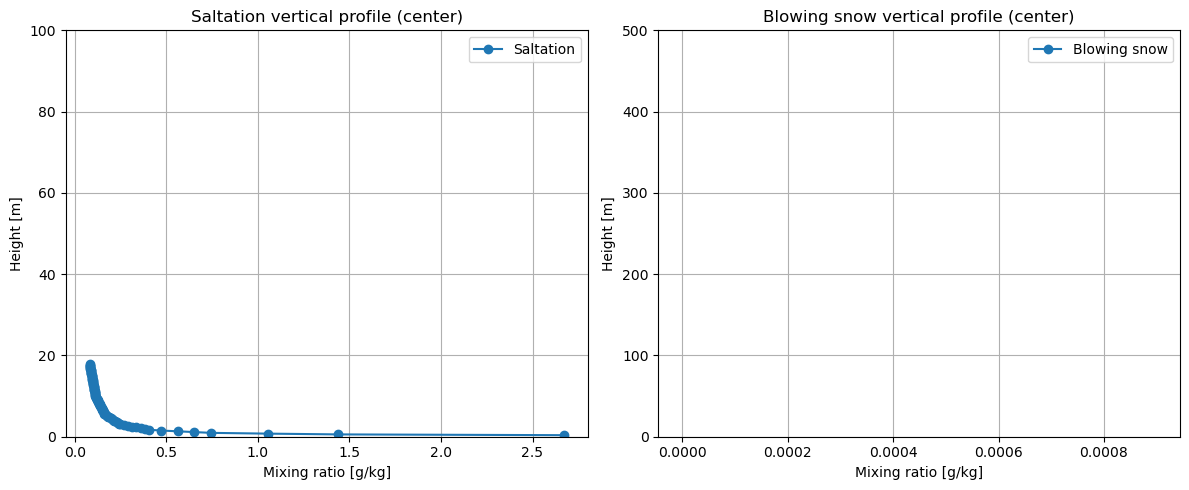

In [46]:
# Check saltation data
print("Saltation cross-section shape:", sn_qs_cross.shape)
print("Saltation vertical coord range:", sn_qs_cross.coords["vertical"].min().values, "to", sn_qs_cross.coords["vertical"].max().values)
print("Saltation data range (kg/kg):", sn_qs_cross.min().values, "to", sn_qs_cross.max().values)
print("Saltation data range (g/kg):", sn_qs_cross.min().values * 1000, "to", sn_qs_cross.max().values * 1000)
print("\nBlowing snow cross-section shape:", bs_qi_cross.shape)
print("Blowing snow vertical coord range:", bs_qi_cross.coords["vertical"].min().values, "to", bs_qi_cross.coords["vertical"].max().values)
print("Blowing snow data range (kg/kg):", bs_qi_cross.min().values, "to", bs_qi_cross.max().values)
print("Blowing snow data range (g/kg):", bs_qi_cross.min().values * 1000, "to", bs_qi_cross.max().values * 1000)

# Plot vertical profiles at center point
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

center_idx = len(terrain) // 2
axes[0].plot(sn_qs_cross[:, center_idx] * 1000, sn_qs_cross.coords["vertical"], 'o-', label='Saltation')
axes[0].set_xlabel('Mixing ratio [g/kg]')
axes[0].set_ylabel('Height [m]')
axes[0].set_title('Saltation vertical profile (center)')
axes[0].grid(True)
axes[0].legend()
axes[0].set_ylim(0, 100)  # Focus on near-surface

axes[1].plot(bs_qi_cross[:, center_idx] * 1000, bs_qi_cross.coords["vertical"], 'o-', label='Blowing snow')
axes[1].set_xlabel('Mixing ratio [g/kg]')
axes[1].set_ylabel('Height [m]')
axes[1].set_title('Blowing snow vertical profile (center)')
axes[1].grid(True)
axes[1].legend()
axes[1].set_ylim(0, 500)  # Show lower atmosphere

plt.tight_layout()
plt.show()


In [ ]:
from matplotlib.colors import LogNorm

# Example usage:
coords_PEA = (-71.9499, 23.3470)
vmin_T= -12
vmax_T= 12
vmin_UV= 0
vmax_UV= 45

for time_idx in range(0, len(theta.Time), 2):
    results = create_simple_cross_section(
        wrflist=wrflist,
        center_lat=coords_PEA[0],
        center_lon=coords_PEA[1],
        direction_deg=155,
        length_km=35,
        theta=theta,
        speed=speed,
        bs_qi=bs_qi,
        # sn_qs=sn_qs,
        # sn_c_height=sn_c_height,
        u=u,
        v=v,
        w=w,
        z=z,
        ter=ter,
        time_idx=time_idx
    )

    theta_cross = results['theta_cross']
    speed_cross = results['speed_cross']
    bs_qi_cross = results['bs_qi_cross']
    # sn_qs_cross = results['sn_qs_cross']
    terrain = results['ter_cross']
    w_cross = results['w_cross']
    h_wind_cross = results['h_wind_cross']

    xy_loc = theta_cross.coords["xy_loc"]
    lats = np.array(wrf.pairs_to_latlon(wrf.to_np(xy_loc))[0])
    lons = np.array(wrf.pairs_to_latlon(wrf.to_np(xy_loc))[1])

    distances = np.sqrt((lats - coords_PEA[0])**2 + (lons - coords_PEA[1])**2)
    pea_idx = np.argmin(distances)

    x_labels = [f"{lat:.2f}°\n{lon:.2f}°" for lat, lon in zip(lats[::10], lons[::10])]
    x_positions = np.arange(len(terrain))[::10]

    # Plot with terrain and vertical coordinates in meters
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    # Temperature cross-section
    cf0 = axes[0].contourf(np.arange(len(terrain)), theta_cross.coords["vertical"], theta_cross - 273.15, 
                            levels=40, cmap='RdYlBu_r', vmin=vmin_T, vmax=vmax_T)
    axes[0].fill_between(np.arange(len(terrain)), 0, terrain, color='saddlebrown', zorder=10)
    axes[0].axvline(x=pea_idx, color='red', linestyle='--', linewidth=2, label='PEA Station')
    axes[0].set_ylabel('Height [m]')
    axes[0].set_title('Potential Temperature [°C]')
    axes[0].legend(loc='upper right')
    plt.colorbar(cf0, ax=axes[0], label='°C')
    axes[0].set_ylim(terrain.min(), 3700)
    axes[0].set_xticks(x_positions)
    axes[0].set_xticklabels([])

    # Wind speed cross-section with wind vectors
    intervalx = 8
    intervaly = 8
    widthfactor = 0.002
    scalefactor = 400

    cf1 = axes[1].contourf(np.arange(len(terrain)), speed_cross.coords["vertical"], speed_cross, 
                            levels=40, cmap='YlGn', vmin=vmin_UV, vmax=vmax_UV)
    axes[1].fill_between(np.arange(len(terrain)), 0, terrain, color='saddlebrown', zorder=10)
    axes[1].quiver(np.arange(len(terrain))[::intervalx], speed_cross.coords["vertical"][::intervaly], 
                wrf.to_np(h_wind_cross[::intervaly, ::intervalx]), 
                wrf.to_np(w_cross[::intervaly, ::intervalx]), 
                color='k', width=widthfactor, scale=scalefactor, zorder=20)
    axes[1].axvline(x=pea_idx, color='red', linestyle='--', linewidth=2, label='PEA Station')
    axes[1].set_ylabel('Height [m]')
    axes[1].set_title('Wind Speed [m/s]')
    axes[1].legend(loc='upper right')
    plt.colorbar(cf1, ax=axes[1], label='m/s')
    axes[1].set_ylim(terrain.min(), 3700)
    axes[1].set_xticks(x_positions)
    axes[1].set_xticklabels([])
    
    # Convert to g/kg for both variables
    bs_qi_data = bs_qi_cross * 1000
    # sn_qs_data = sn_qs_cross * 1000
    sn_qs_data = np.zeros_like(bs_qi_data)  # Placeholder if sn_qs_cross is not available
    
    # Find global min/max for consistent color scale
    # Only include sn_qs_data if it's not all zeros (i.e., when it's actually available)
    if np.any(sn_qs_data > 0):
        all_data = np.concatenate([bs_qi_data.values.flatten(), sn_qs_data.flatten()])
    else:
        all_data = bs_qi_data.values.flatten()
    
    all_data = all_data[all_data > 0]  # Remove zeros/negatives
    vmin = np.nanmin(all_data) if len(all_data) > 0 else 1e-6
    vmax = np.nanmax(all_data) if len(all_data) > 0 else 1.0
    
    if vmin <= 0:
        vmin = 1e-6
    vmax= 2e-1
    levels = np.logspace(np.log10(vmin), np.log10(vmax), 50)
    
    # Plot bs_qi (atmospheric blowing snow)
    cf2 = axes[2].contourf(np.arange(len(terrain)), bs_qi_cross.coords["vertical"], 
                        bs_qi_data, 
                        levels=200, 
                        cmap='Blues',
                        alpha=0.7,
                        vmin=vmin, vmax=vmax,
                        norm=LogNorm(vmin=vmin, vmax=vmax)
                        )
    

    # # Overlay sn_qs (saltation layer)
    # cf3 = axes[2].contourf(np.arange(len(terrain)), sn_qs_cross.coords["vertical"], 
    #                     sn_qs_data, 
    #                     levels=20, 
    #                     cmap='Oranges',
    #                     alpha=0.7)
    
    axes[2].fill_between(np.arange(len(terrain)), 0, terrain, color='saddlebrown', zorder=10)
    axes[2].axvline(x=pea_idx, color='red', linestyle='--', linewidth=2, label='PEA Station')
    axes[2].set_ylabel('Height [m]')
    axes[2].set_xlabel('Latitude / Longitude')
    axes[2].set_title('Blowing Snow [g/kg]')
    axes[2].legend(loc='upper right')
    plt.colorbar(cf2, ax=axes[2], label='g/kg', extend='max')
    axes[2].set_ylim(terrain.min(), 3700)
    axes[2].set_xticks(x_positions)
    axes[2].set_xticklabels(x_labels, fontsize=8)
    plt.suptitle(pd.Timestamp(theta.Time[time_idx].values).strftime('Cross-Section at %Y-%m-%d %H:%M:%S UTC'), fontsize=16)
    plt.tight_layout()
    plt.savefig(f'/capstor/scratch/cscs/rengbers/results_PE_figs/cross_sec/cross_section_{time_idx:03d}.pdf', dpi=300)
    # plt.show()


Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72

/tmp/ipykernel_167395/3275505846.py:49: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3, 1, figsize=(14, 12))


Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72.0928, 23.4136)
Direction: 155° (meteorological convention)
Cross-section from (-71.8070, 23.2804) to (-72

In [ ]:
plt.close()

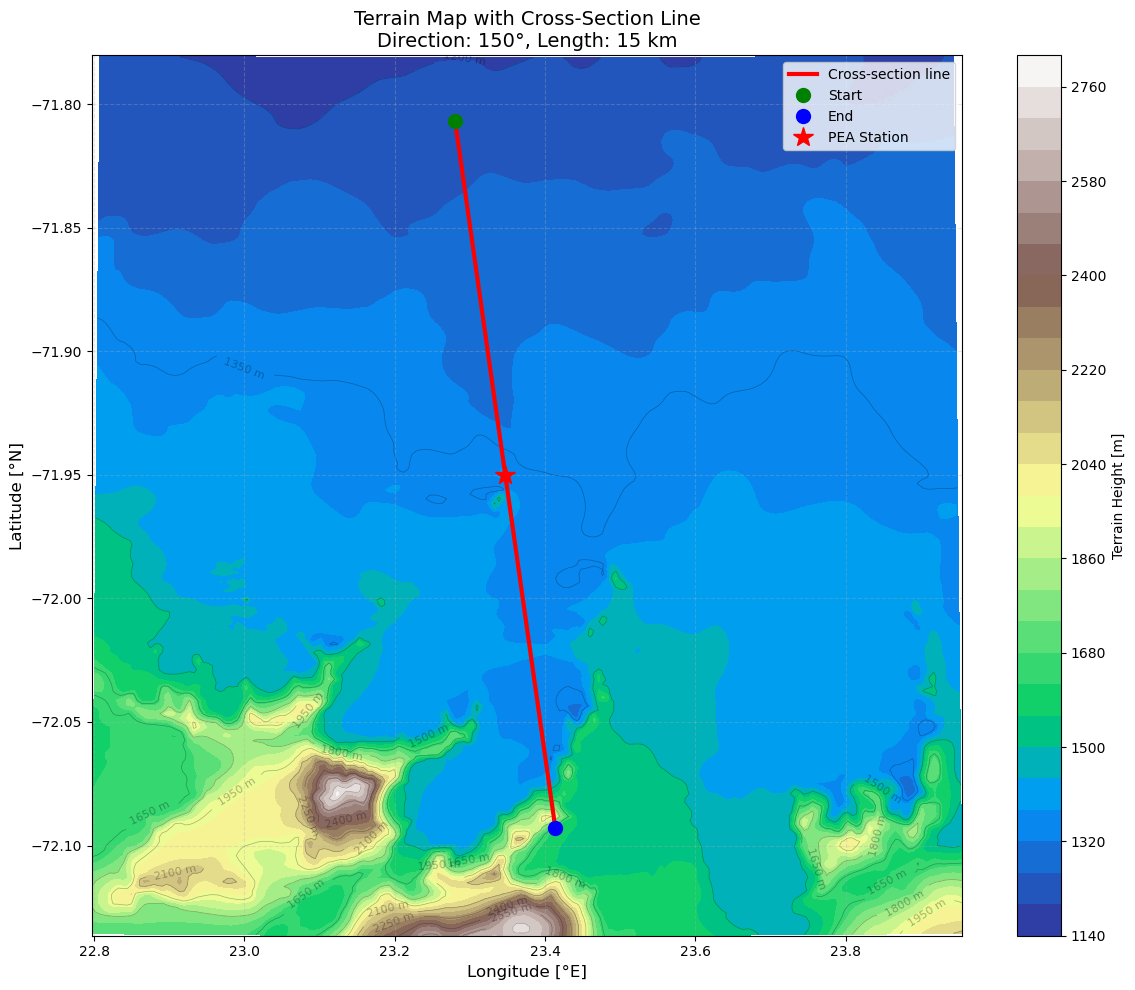

In [71]:
# Create a terrain map showing the cross-section line
fig, ax = plt.subplots(figsize=(12, 10))

# Get lat/lon coordinates from terrain
lats_grid, lons_grid = wrf.latlon_coords(ter)

# Plot terrain as filled contours
terrain_plot = ax.contourf(lons_grid, lats_grid, ter, levels=30, cmap='terrain')
plt.colorbar(terrain_plot, ax=ax, label='Terrain Height [m]')

# Add terrain contour lines
contour_lines = ax.contour(lons_grid, lats_grid, ter, levels=10, colors='black', alpha=0.3, linewidths=0.5)
ax.clabel(contour_lines, inline=True, fontsize=8, fmt='%d m')

# Plot the cross-section line
cross_start = results['start_point']
cross_end = results['end_point']
ax.plot([cross_start.lon, cross_end.lon], [cross_start.lat, cross_end.lat], 
        'r-', linewidth=3, label='Cross-section line', zorder=10)

# Mark start and end points
ax.plot(cross_start.lon, cross_start.lat, 'go', markersize=10, label='Start', zorder=11)
ax.plot(cross_end.lon, cross_end.lat, 'bo', markersize=10, label='End', zorder=11)

# Mark PEA station
ax.plot(coords_PEA[1], coords_PEA[0], 'r*', markersize=15, label='PEA Station', zorder=12)

# Add labels and formatting
ax.set_xlabel('Longitude [°E]', fontsize=12)
ax.set_ylabel('Latitude [°N]', fontsize=12)
ax.set_title(f'Terrain Map with Cross-Section Line\nDirection: {150}°, Length: {15} km', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


In [23]:
print('t2 shape:', t2.shape)
print('t2_d03 shape:', t2_d03.shape)
lats_check, lons_check = wrf.latlon_coords(t2)
lats_check_d03, lons_check_d03 = wrf.latlon_coords(t2_d03)
print('t2 lat/lon minmax:', float(lats_check.min()), float(lats_check.max()), float(lons_check.min()), float(lons_check.max()))
print('t2_d03 lat/lon minmax:', float(lats_check_d03.min()), float(lats_check_d03.max()), float(lons_check_d03.min()), float(lons_check_d03.max()))

t2 shape: (577, 150, 150)
t2_d03 shape: (577, 150, 150)
t2 lat/lon minmax: -72.64225006103516 -71.29930877685547 21.025299072265625 25.48906707763672
t2_d03 lat/lon minmax: -72.64225006103516 -71.29930877685547 21.025299072265625 25.48906707763672
